# Guided Numeric Exploration — Credit Card Customer Behavior
_Spend mix, utilization risk, correlations, regression, and card×occupation structure in a synthetic 50k-customer panel_

***

**Programming Language:** Python in the Jupyter Notebook Environment

**Dataset:** [dharmendrapandit12/credit-card-customer-behavior-segmentation-dataset](https://www.kaggle.com/datasets/dharmendrapandit12/credit-card-customer-behavior-segmentation-dataset)

**Style counterpart:** [Guided Numeric and Text Exploration — E-Commerce](https://www.kaggle.com/code/nicapotato/guided-numeric-and-text-exploration-e-commerce)

**Code Navigation:** <br>
In the code, text after hashtags (`#`) are supportive explanations, not executed as code.

***



# Tables of Content:

**1. [Introduction](#Introduction)** <br>
**2. [Setup and Data Peek](#Setup)** <br>
**3. [Univariate Distributions](#Univariate)** <br>
**4. [Card Type × Occupation](#CardOcc)** <br>
**5. [Spend-Mix Shares](#SpendMix)** <br>
**6. [Risk: Utilization × Payment × Score](#Risk)** <br>
**7. [Top Correlations](#Correlations)** <br>
**8. [Linear Regression](#Regression)** <br>
**9. [Multivariate Association (RF)](#Association)** <br>
**10. [Optional PCA / KMeans Segments](#Clusters)** <br>
**11. [What It Means — Working Synthesis](#Synthesis)** <br>

# **1. Introduction:** <a id="Introduction"></a> <br>
This is a **synthetic** 50,000-customer credit-card panel with demographics, card product, category spend, balances, payment behavior, rewards, and `Credit_Score`. Treat associations as properties of the generator — useful for segmentation and risk drills, not for quoting real portfolio rates.

Card products for ordered plots: **Basic → Silver → Gold → Platinum → Signature**.



# **2. Setup and Data Peek:** <a id="Setup"></a>


In [1]:
# General
import numpy as np
import pandas as pd
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Scientific / modeling helpers
from IPython.display import display
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import kagglehub

# Set Plot Theme (same family as the e-commerce guided notebook)
sns.set_palette([
    "#30a2da",
    "#fc4f30",
    "#e5ae38",
    "#6d904f",
    "#8b8b8b",
])
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Wide table inspection in Jupyter cell outputs
pd.set_option("display.max_columns", 999)
pd.set_option("display.width", 220)



/Users/nicapotato/Documents/repo/project/KaggleNotebooks/eda/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Code Explanation and Reasoning:** <br>
These packages fall into three buckets: *General*, *Visualization*, and *Scientific / modeling helpers*.

`pandas` / `numpy` hold the table; `matplotlib` / `seaborn` do the graphics; `scipy` and `sklearn` support light associational checks (correlations, RandomForest importances, optional PCA/clustering), not a production model. `kagglehub` resolves files both on Kaggle (`/kaggle/input/...`) and locally.

The five-color palette matches the guided e-commerce notebook so sequential plots feel like one continuous exploration.

`LinearRegression`, `train_test_split`, and regression metrics support the correlation → OLS → RF ladder in sections 7–9.


In [2]:
# Read and Peak at Data
CSV_BASENAME = "synthetic_credit_card_customer_behavior_dataset.csv"
KAGGLE_SLUG = "dharmendrapandit12/credit-card-customer-behavior-segmentation-dataset"
EXPECTED_COLS = [
    "Customer_ID", "Age", "Gender", "Annual_Income", "Occupation", "Card_Type",
    "Credit_Limit", "Card_Age_Months", "Monthly_Spending", "Monthly_Transactions",
    "Avg_Transaction_Value", "Online_Shopping_Spending", "Grocery_Spending", "Fuel_Spending",
    "Dining_Spending", "Travel_Spending", "Entertainment_Spending", "Utility_Bill_Spending",
    "Outstanding_Balance", "Statement_Balance", "Payment_Amount", "Payment_Ratio",
    "Credit_Utilization", "Cash_Advance_Amount", "EMI_Count", "International_Transactions",
    "Reward_Points_Earned", "Reward_Points_Redeemed", "Mobile_App_Login", "Credit_Score",
]
CARD_ORDER = ["Basic", "Silver", "Gold", "Platinum", "Signature"]
SPEND_COLS = [
    "Online_Shopping_Spending", "Grocery_Spending", "Fuel_Spending", "Dining_Spending",
    "Travel_Spending", "Entertainment_Spending", "Utility_Bill_Spending",
]


def resolve_csv_path(basename: str = CSV_BASENAME) -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(basename):
            return p
    local_data = Path("data") / basename
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / basename
    if not p.exists():
        hits = list(root.rglob(basename))
        assert hits, f"expected {basename} under {root}"
        p = hits[0]
    return p


csv_path = resolve_csv_path()
print("CSV:", csv_path)
df = pd.read_csv(csv_path, low_memory=False)
missing = set(EXPECTED_COLS) - set(df.columns)
assert not missing, f"missing columns: {sorted(missing)}"
assert len(df) == 50000, f"expected 50000 rows, got {len(df)}"
assert df.shape[1] == 30, f"expected 30 cols, got {df.shape[1]}"
assert df.isnull().sum().sum() == 0, "expected zero nulls in synthetic panel"
assert set(df["Card_Type"].unique()).issubset(set(CARD_ORDER))
df["Card_Type"] = pd.Categorical(df["Card_Type"], categories=CARD_ORDER, ordered=True)

print("Missing Values:", int(df.isnull().sum().sum()))
print("Dataframe Dimension: {} Rows, {} Columns".format(*df.shape))
print("Credit_Score mean/median:", round(df["Credit_Score"].mean(), 1), round(df["Credit_Score"].median(), 1))
display(df.sample(5, random_state=7))


Missing Values: 0
Dataframe Dimension: 50000 Rows, 30 Columns
Credit_Score mean/median: 629.0 638.0


,Customer_ID,Age,Gender,Annual_Income,Occupation,Card_Type,Credit_Limit,Card_Age_Months,Monthly_Spending,Monthly_Transactions,Avg_Transaction_Value,Online_Shopping_Spending,Grocery_Spending,Fuel_Spending,Dining_Spending,Travel_Spending,Entertainment_Spending,Utility_Bill_Spending,Outstanding_Balance,Statement_Balance,Payment_Amount,Payment_Ratio,Credit_Utilization,Cash_Advance_Amount,EMI_Count,International_Transactions,Reward_Points_Earned,Reward_Points_Redeemed,Mobile_App_Login,Credit_Score
29430,CC129430,18,M,702222,Private Employee,Silver,214000.0,80,28503.71,30,969.95,1414.86,6572.64,1782.37,7167.73,1971.91,5591.02,4003.17,149693.68,170776.82,90511.71,0.53,0.72,0.00,2,0,839,155,18,527
27750,CC127750,21,M,1058336,Self-Employed,Silver,319000.0,34,68693.75,178,382.85,2220.83,13738.91,6717.39,18833.49,16643.46,5338.94,5200.72,108435.48,175748.73,172233.76,0.98,0.35,0.00,2,0,2039,1138,38,700
47782,CC147782,59,F,1577098,Private Employee,Gold,683000.0,69,86637.29,158,573.58,10659.81,25192.65,12049.32,16807.43,4340.58,5564.05,12023.46,436672.25,517866.77,497152.10,0.96,0.63,0.00,3,1,3396,0,58,638
10498,CC110498,30,F,351019,Retired,Basic,64000.0,44,14520.30,21,696.24,1259.78,2201.45,474.56,3983.98,1478.78,1573.89,3547.87,38696.20,51549.68,49487.69,0.96,0.59,12576.46,0,0,295,65,6,624
24747,CC124747,44,M,1461168,Government Employee,Gold,619000.0,42,102775.66,99,1063.65,9784.80,15818.17,20155.25,14601.57,9162.78,11244.62,22008.47,396726.61,472616.76,444259.75,0.94,0.66,0.00,3,3,4054,1214,45,637


**Code Explanation and Reasoning:** <br>
Schema, 50k×30 shape, and the zero-null claim are asserted. `Card_Type` is cast to an ordered categorical so later boxplots and heatmaps keep the Basic→Signature ladder.


In [3]:
unique_count = [[c, df[c].nunique(dropna=False), int(df[c].isnull().sum())] for c in df.columns]
display(pd.DataFrame(unique_count, columns=["Column", "Unique", "Null"]).sort_values("Unique", ascending=False))
df[["Age", "Annual_Income", "Monthly_Spending", "Credit_Utilization", "Payment_Ratio", "Credit_Score"]].describe().round(2)


,Column,Unique,Null
0,Customer_ID,50000,0
19,Statement_Balance,49980,0
20,Payment_Amount,49971,0
18,Outstanding_Balance,49970,0
8,Monthly_Spending,49900,0
12,Grocery_Spending,49588,0
3,Annual_Income,49485,0
17,Utility_Bill_Spending,49359,0
11,Online_Shopping_Spending,49287,0
13,Fuel_Spending,49264,0


,Age,Annual_Income,Monthly_Spending,Credit_Utilization,Payment_Ratio,Credit_Score
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,36.08,1479317.91,73871.80,0.43,0.76,628.98
std,12.24,1407257.48,84338.27,0.21,0.24,68.44
min,18.00,100050.00,2235.63,0.10,0.10,367.00
25%,27.00,657774.25,26646.49,0.27,0.62,585.00
50%,34.00,1127629.50,50022.38,0.40,0.84,638.00
75%,44.00,1663624.00,83029.96,0.56,0.96,681.00
max,70.00,7995831.00,691687.96,0.95,1.00,792.00


**Interpretation** <br>
Income and spending are right-skewed; utilization and payment ratio sit on [0, 1]-ish scales. Card type and occupation are the main product/segment axes for the next sections.


# **3. Univariate Distributions:** <a id="Univariate"></a>


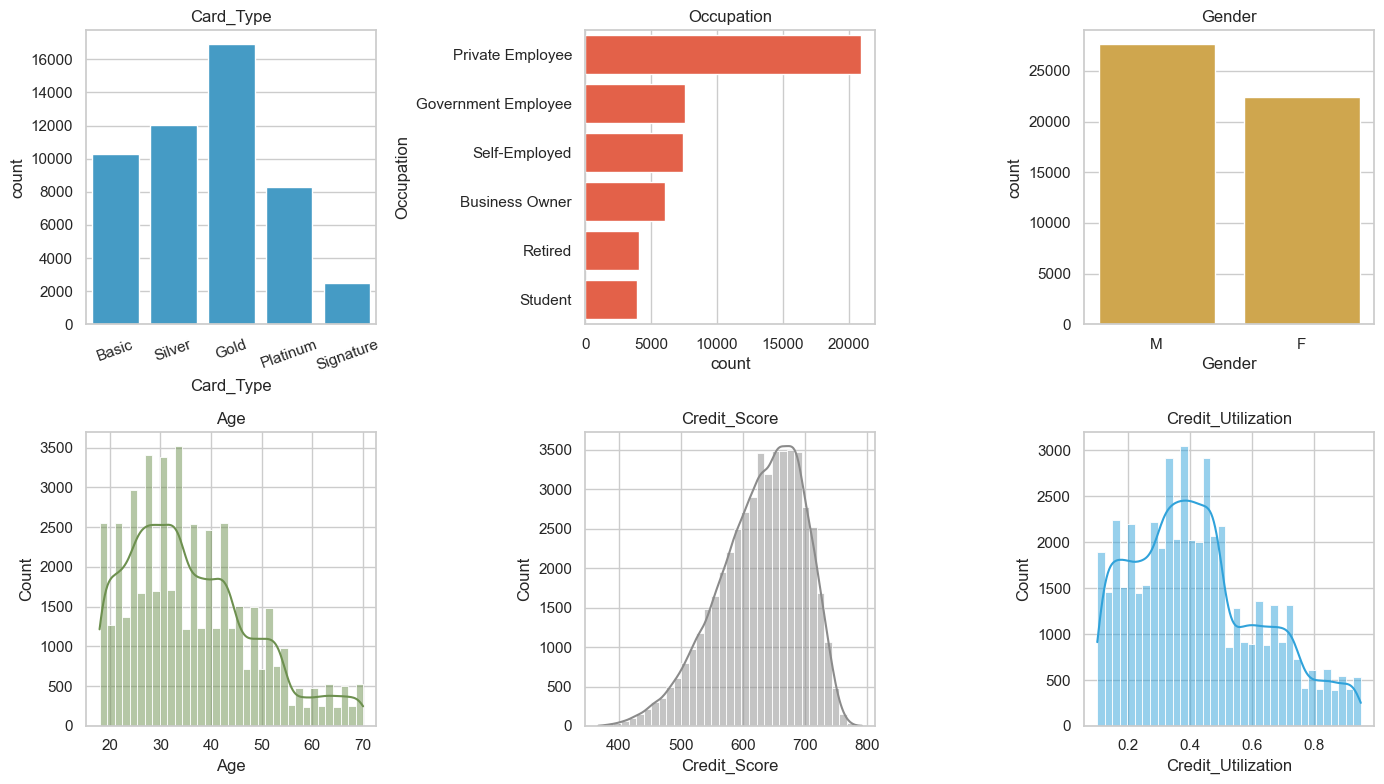

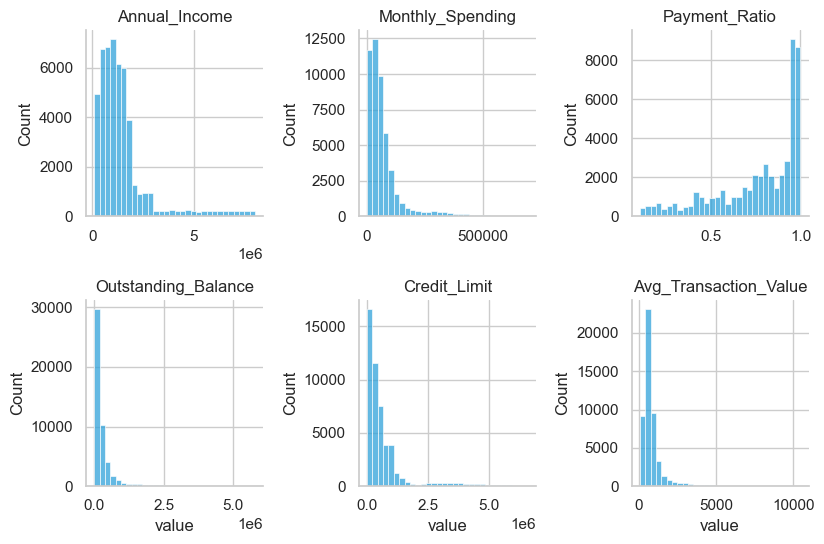

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
sns.countplot(data=df, x="Card_Type", order=CARD_ORDER, ax=axes[0], color="#30a2da")
axes[0].set_title("Card_Type")
axes[0].tick_params(axis="x", rotation=20)
sns.countplot(data=df, y="Occupation",
              order=df["Occupation"].value_counts().index, ax=axes[1], color="#fc4f30")
axes[1].set_title("Occupation")
sns.countplot(data=df, x="Gender", ax=axes[2], color="#e5ae38")
axes[2].set_title("Gender")
for ax, col, color in [
    (axes[3], "Age", "#6d904f"),
    (axes[4], "Credit_Score", "#8b8b8b"),
    (axes[5], "Credit_Utilization", "#30a2da"),
]:
    sns.histplot(df[col], bins=35, kde=True, ax=ax, color=color)
    ax.set_title(col)
plt.tight_layout()
plt.show()

cont = ["Annual_Income", "Monthly_Spending", "Payment_Ratio", "Outstanding_Balance",
        "Credit_Limit", "Avg_Transaction_Value"]
melt = df[cont].melt(var_name="feature", value_name="value")
g = sns.FacetGrid(melt, col="feature", col_wrap=3, sharex=False, sharey=False, height=2.8)
g.map_dataframe(sns.histplot, x="value", bins=30, color="#30a2da")
g.set_titles("{col_name}")
plt.show()


**Interpretation** <br>
Gold dominates card mix; Signature is the thin premium tail. Private employees are the modal occupation. Utilization and score distributions set up the risk section — look for whether premium cards also hold healthier payment behavior.


# **4. Card Type × Occupation:** <a id="CardOcc"></a>


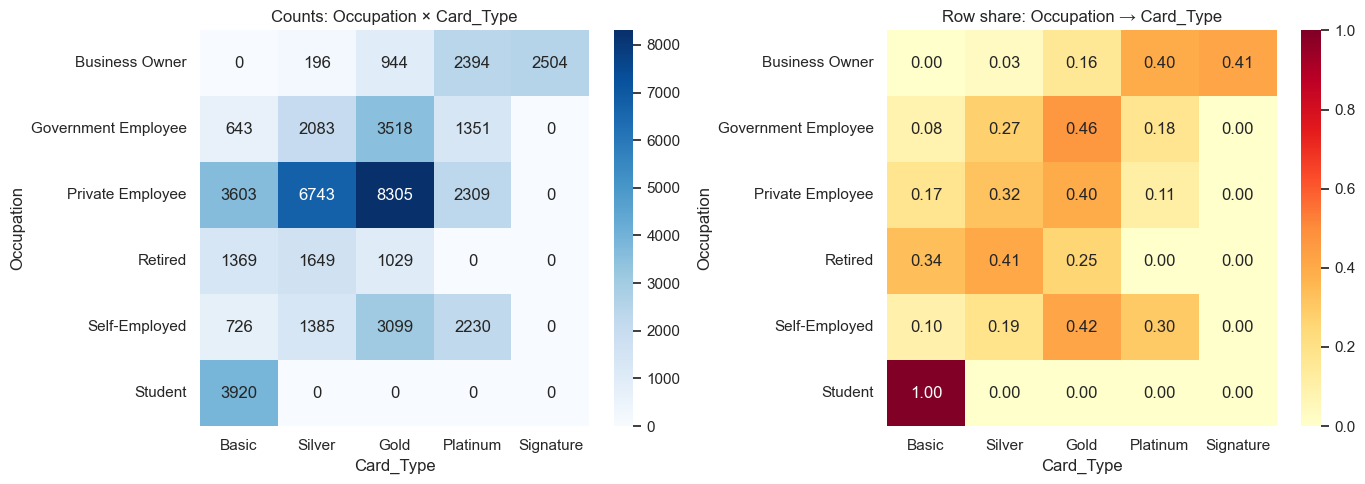

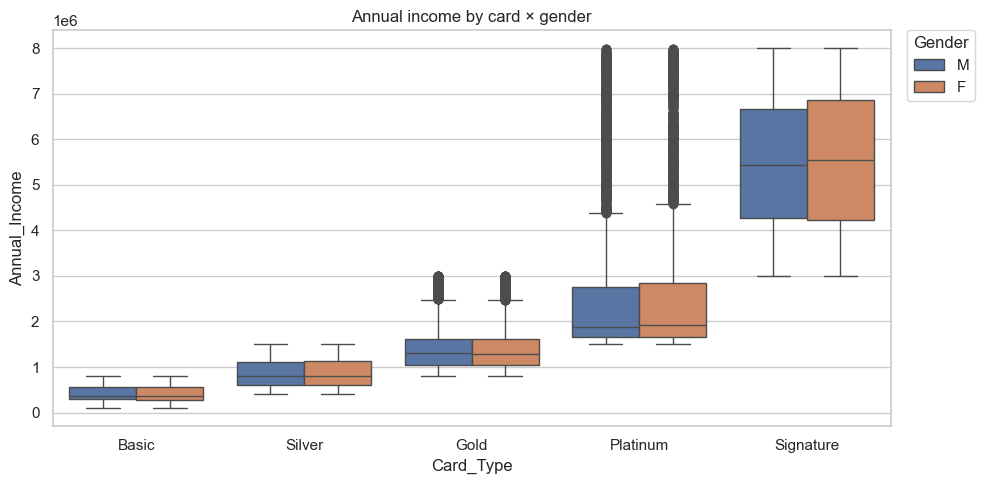

,Credit_Limit,Monthly_Spending,Credit_Score
Card_Type,,,
Basic,66000.0,15066.8,637.0
Silver,227000.0,34829.1,636.0
Gold,519000.0,60466.4,635.0
Platinum,1053500.0,106912.5,643.0
Signature,4094500.0,304722.7,645.0


In [5]:
# Counts and row-% composition
card_occ_n = pd.crosstab(df["Occupation"], df["Card_Type"])
card_occ_pct = pd.crosstab(df["Occupation"], df["Card_Type"], normalize="index").reindex(columns=CARD_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(card_occ_n.reindex(columns=CARD_ORDER), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Counts: Occupation × Card_Type")
sns.heatmap(card_occ_pct, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1], vmin=0, vmax=1)
axes[1].set_title("Row share: Occupation → Card_Type")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="Card_Type", y="Annual_Income", order=CARD_ORDER, hue="Gender", ax=ax)
ax.set_title("Annual income by card × gender")
ax.legend(title="Gender", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

med = df.groupby("Card_Type", observed=True)[["Credit_Limit", "Monthly_Spending", "Credit_Score"]].median()
display(med.round(1))


**Interpretation** <br>
Row shares ask whether occupations concentrate in premium products. Income boxes by card should ladder upward if the generator ties product to affluence; gender hue checks whether that ladder is shared.


# **5. Spend-Mix Shares:** <a id="SpendMix"></a>


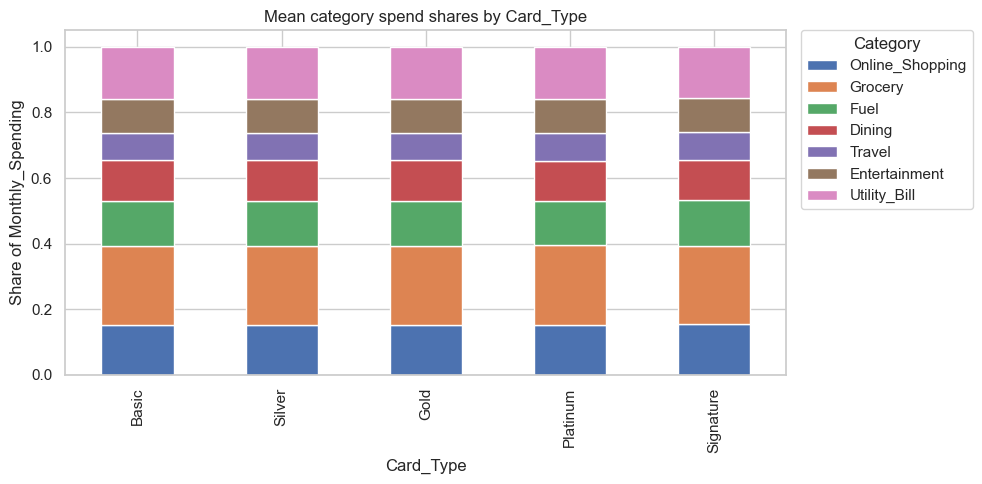

,Online_Shopping,Grocery,Fuel,Dining,Travel,Entertainment,Utility_Bill
Card_Type,,,,,,,
Basic,0.151,0.241,0.139,0.123,0.082,0.104,0.159
Silver,0.152,0.241,0.137,0.124,0.084,0.104,0.158
Gold,0.152,0.241,0.138,0.124,0.083,0.103,0.159
Platinum,0.152,0.243,0.137,0.122,0.083,0.104,0.160
Signature,0.154,0.239,0.139,0.123,0.085,0.104,0.157


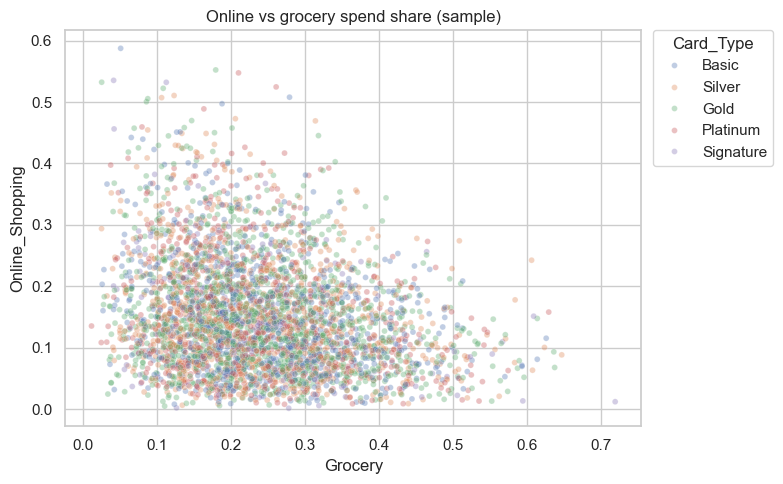

In [6]:
# Category spend as share of monthly spending (assert positive monthly spend)
assert (df["Monthly_Spending"] > 0).all()
share = df[SPEND_COLS].div(df["Monthly_Spending"], axis=0)
share.columns = [c.replace("_Spending", "") for c in SPEND_COLS]
share["Card_Type"] = df["Card_Type"].values

mean_share = share.groupby("Card_Type", observed=True)[share.columns[:-1]].mean().reindex(CARD_ORDER)
fig, ax = plt.subplots(figsize=(10, 5))
mean_share.plot(kind="bar", stacked=True, ax=ax, color=sns.color_palette()[: mean_share.shape[1]])
ax.set_title("Mean category spend shares by Card_Type")
ax.set_ylabel("Share of Monthly_Spending")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()
display(mean_share.round(3))

# Online vs grocery share scatter by card
plot_df = share.sample(4000, random_state=7)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=plot_df, x="Grocery", y="Online_Shopping", hue="Card_Type",
    hue_order=CARD_ORDER, alpha=0.35, s=18, ax=ax,
)
ax.set_title("Online vs grocery spend share (sample)")
ax.legend(title="Card_Type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()


**Interpretation** <br>
Stacked shares show whether premium cards tilt toward travel/dining/entertainment vs grocery/utility. The scatter is a noise check — if categories are near-independent of card, the generator is soft on lifestyle differentiation.


# **6. Risk: Utilization × Payment × Score:** <a id="Risk"></a>


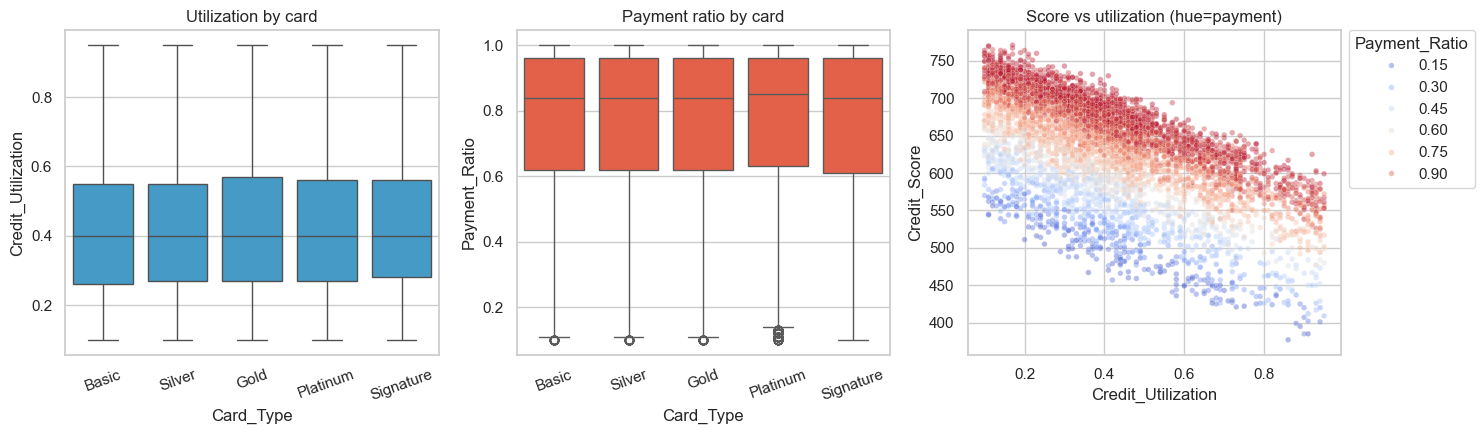

,n,high_util_rate,mean_payment,mean_score,cash_adv_rate
Card_Type,,,,,
Basic,10261,0.120,0.761,628.518,0.298
Silver,12056,0.131,0.763,627.133,0.292
Gold,16895,0.132,0.763,626.782,0.299
Platinum,8284,0.126,0.767,634.230,0.297
Signature,2504,0.126,0.761,637.317,0.297


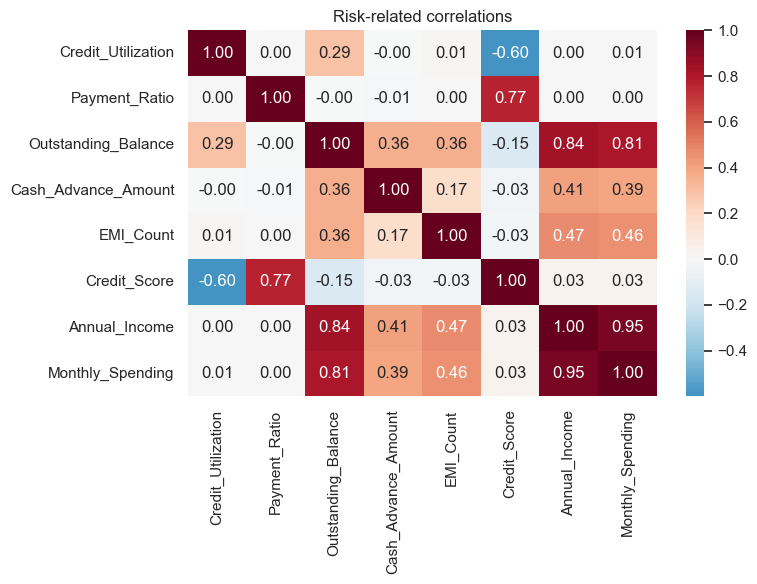

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(data=df, x="Card_Type", y="Credit_Utilization", order=CARD_ORDER, ax=axes[0], color="#30a2da")
axes[0].set_title("Utilization by card")
axes[0].tick_params(axis="x", rotation=20)
sns.boxplot(data=df, x="Card_Type", y="Payment_Ratio", order=CARD_ORDER, ax=axes[1], color="#fc4f30")
axes[1].set_title("Payment ratio by card")
axes[1].tick_params(axis="x", rotation=20)
sns.scatterplot(
    data=df.sample(5000, random_state=7),
    x="Credit_Utilization", y="Credit_Score", hue="Payment_Ratio",
    palette="coolwarm", alpha=0.4, s=16, ax=axes[2],
)
axes[2].set_title("Score vs utilization (hue=payment)")
axes[2].legend(title="Payment_Ratio", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

# High utilization flag
df["high_util"] = (df["Credit_Utilization"] >= 0.7).astype(int)
risk = df.groupby("Card_Type", observed=True).agg(
    n=("Customer_ID", "size"),
    high_util_rate=("high_util", "mean"),
    mean_payment=("Payment_Ratio", "mean"),
    mean_score=("Credit_Score", "mean"),
    cash_adv_rate=("Cash_Advance_Amount", lambda s: (s > 0).mean()),
).reindex(CARD_ORDER)
display(risk.round(3))

corr_cols = ["Credit_Utilization", "Payment_Ratio", "Outstanding_Balance", "Cash_Advance_Amount",
             "EMI_Count", "Credit_Score", "Annual_Income", "Monthly_Spending"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Risk-related correlations")
plt.tight_layout()
plt.show()


**Interpretation** <br>
Utilization and payment ratio by card ask whether premium products also look safer. Score vs utilization with payment hue is the classic risk triangle in this generator. `high_util` (≥0.7) becomes a modeling target next to continuous `Credit_Score`.


# **7. Top Correlations:** <a id="Correlations"></a>


In [ ]:
# Numeric panel (IDs / engineered flags excluded from the matrix core)
num_cols = [
    c for c in df.select_dtypes(include="number").columns
    if c not in {"Customer_ID", "high_util"}
]
assert "Credit_Score" in num_cols

corr = df[num_cols].corr()

# Compact heatmap of behavior / risk / score (full matrix is wide)
heat_cols = [
    "Age", "Annual_Income", "Credit_Limit", "Monthly_Spending", "Monthly_Transactions",
    "Outstanding_Balance", "Payment_Ratio", "Credit_Utilization", "Cash_Advance_Amount",
    "EMI_Count", "Reward_Points_Earned", "Credit_Score",
] + SPEND_COLS
missing_heat = set(heat_cols) - set(num_cols)
assert not missing_heat, missing_heat

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    df[heat_cols].corr(), annot=False, cmap="RdBu_r", center=0, ax=ax,
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Behavior / risk / score correlations")
plt.tight_layout()
plt.show()

# Top |r| with Credit_Score
score_corr = (
    corr["Credit_Score"]
    .drop("Credit_Score")
    .reindex(corr["Credit_Score"].drop("Credit_Score").abs().sort_values(ascending=False).index)
)
top_score = score_corr.head(12).rename("r_with_Credit_Score").to_frame()
top_score["abs_r"] = top_score["r_with_Credit_Score"].abs()
display(top_score.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=top_score["r_with_Credit_Score"].values,
    y=top_score.index,
    ax=ax,
    palette=["#30a2da" if v >= 0 else "#fc4f30" for v in top_score["r_with_Credit_Score"]],
)
ax.axvline(0, color="black", lw=1)
ax.set_title("Top |Pearson r| with Credit_Score")
ax.set_xlabel("Pearson r")
plt.tight_layout()
plt.show()

# Strongest pairwise associations overall (upper triangle, exclude self)
pairs = []
cols = corr.columns.tolist()
for i, a in enumerate(cols):
    for b in cols[i + 1 :]:
        r = float(corr.loc[a, b])
        pairs.append({"feature_a": a, "feature_b": b, "r": r, "abs_r": abs(r)})
pair_df = pd.DataFrame(pairs).sort_values("abs_r", ascending=False)
top_pairs = pair_df.head(15).reset_index(drop=True)
display(top_pairs.round(3))

# Spotlight scatter for the strongest score associate
top_feat = top_score.index[0]
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=df.sample(5000, random_state=7),
    x=top_feat, y="Credit_Score", hue="Card_Type", hue_order=CARD_ORDER,
    alpha=0.35, s=16, ax=ax,
)
ax.set_title(f"Credit_Score vs {top_feat} (strongest |r|; sample)")
ax.legend(title="Card_Type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()
print("Strongest |r| with Credit_Score:", top_feat, round(float(top_score.iloc[0]["r_with_Credit_Score"]), 3))
print("Strongest pairwise |r|:", top_pairs.loc[0, "feature_a"], "↔", top_pairs.loc[0, "feature_b"],
      round(float(top_pairs.loc[0, "r"]), 3))



**Interpretation** <br>
Pearson *r* ranks linear association only — spend categories that sum into `Monthly_Spending` will show mechanical co-movement. Score leaders are the linear shortlist for the regression next; pair leaders flag redundancy (balance/limit/utilization families) before you trust coefficient magnitudes.


# **8. Linear Regression:** <a id="Regression"></a>


In [ ]:
# Linear models for Credit_Score (+ Payment_Ratio as a second target)
# Omit category spends here: they sum into Monthly_Spending and inflate OLS coefs
# Scale numerics so |coef| are comparable; hold out 20% for honest R^2 / RMSE
feature_num = [
    "Age", "Annual_Income", "Credit_Limit", "Card_Age_Months", "Monthly_Spending",
    "Monthly_Transactions", "Payment_Ratio", "Credit_Utilization", "Cash_Advance_Amount",
    "EMI_Count", "International_Transactions", "Mobile_App_Login", "Reward_Points_Earned",
]
feature_cat = ["Gender", "Occupation", "Card_Type"]
assert set(feature_num + feature_cat).issubset(df.columns)
# Mechanical redundancy checks (generator accounting links)
assert "Outstanding_Balance" not in feature_num  # ~Statement_Balance; utilization already carries balance risk
assert not set(SPEND_COLS) & set(feature_num)

X = df[feature_num + feature_cat]
y_score = df["Credit_Score"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_score, test_size=0.2, random_state=7,
)

pre = ColumnTransformer([
    ("num", StandardScaler(), feature_num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), feature_cat),
])
pipe_lr = Pipeline([
    ("pre", pre),
    ("lr", LinearRegression()),
])
pipe_lr.fit(X_train, y_train)
pred_tr = pipe_lr.predict(X_train)
pred_te = pipe_lr.predict(X_test)

metrics = pd.DataFrame({
    "split": ["train", "test"],
    "R2": [r2_score(y_train, pred_tr), r2_score(y_test, pred_te)],
    "RMSE": [
        float(np.sqrt(mean_squared_error(y_train, pred_tr))),
        float(np.sqrt(mean_squared_error(y_test, pred_te))),
    ],
})
display(metrics.round(3))

# Coefficient table (scaled numeric + OHE cats)
enc = pipe_lr.named_steps["pre"]
lr = pipe_lr.named_steps["lr"]
feat_names = feature_num + list(enc.named_transformers_["cat"].get_feature_names_out(feature_cat))
coef = pd.Series(lr.coef_, index=feat_names).sort_values(key=np.abs, ascending=False)
top_coef = coef.head(15).rename("coef").to_frame()
top_coef["abs_coef"] = top_coef["coef"].abs()
display(top_coef.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    x=top_coef["coef"].values, y=top_coef.index, ax=axes[0],
    palette=["#30a2da" if v >= 0 else "#fc4f30" for v in top_coef["coef"]],
)
axes[0].axvline(0, color="black", lw=1)
axes[0].set_title("Top |standardized coef| → Credit_Score")
axes[0].set_xlabel("LinearRegression coef")

resid = y_test - pred_te
sns.scatterplot(x=pred_te, y=resid, alpha=0.25, s=12, ax=axes[1], color="#8b8b8b")
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Test residuals vs fitted (Credit_Score)")
axes[1].set_xlabel("Fitted")
axes[1].set_ylabel("Residual")
plt.tight_layout()
plt.show()

# Align linear signal with Pearson shortlist (numeric features only)
pearson_vs_coef = pd.DataFrame({
    "pearson_r": corr["Credit_Score"].reindex(feature_num),
    "std_coef": coef.reindex(feature_num),
}).dropna()
pearson_vs_coef["abs_r"] = pearson_vs_coef["pearson_r"].abs()
pearson_vs_coef["abs_coef"] = pearson_vs_coef["std_coef"].abs()
display(pearson_vs_coef.sort_values("abs_coef", ascending=False).round(3))

# Second target: Payment_Ratio from demography / spend / risk inputs (no payment itself)
pay_num = [c for c in feature_num if c != "Payment_Ratio"]
X_pay = df[pay_num + feature_cat]
y_pay = df["Payment_Ratio"]
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_pay, y_pay, test_size=0.2, random_state=7)
pre_pay = ColumnTransformer([
    ("num", StandardScaler(), pay_num),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), feature_cat),
])
pipe_pay = Pipeline([("pre", pre_pay), ("lr", LinearRegression())])
pipe_pay.fit(Xp_tr, yp_tr)
pay_names = pay_num + list(pipe_pay.named_steps["pre"].named_transformers_["cat"].get_feature_names_out(feature_cat))
pay_coef = pd.Series(pipe_pay.named_steps["lr"].coef_, index=pay_names).sort_values(key=np.abs, ascending=False).head(12)
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=pay_coef.values, y=pay_coef.index, ax=ax,
    palette=["#30a2da" if v >= 0 else "#fc4f30" for v in pay_coef.values],
)
ax.axvline(0, color="black", lw=1)
ax.set_title("Top |standardized coef| → Payment_Ratio")
plt.tight_layout()
plt.show()
print(
    "Payment_Ratio LinearRegression test R^2:",
    round(r2_score(yp_te, pipe_pay.predict(Xp_te)), 3),
)


**Interpretation** <br>
Standardized coefficients ask which inputs move `Credit_Score` after controls — not the same ranking as raw Pearson *r* when collinearity is present. Category spends were left out of the OLS feature set because they sum into `Monthly_Spending` and blow up coef magnitudes. Train/test R² gaps flag overfitting; fan-shaped residuals would argue for a non-linear next step (the RF section). The `Payment_Ratio` model is a second linear drill without using payment itself as a feature.


# **9. Multivariate Association (RF):** <a id="Association"></a>



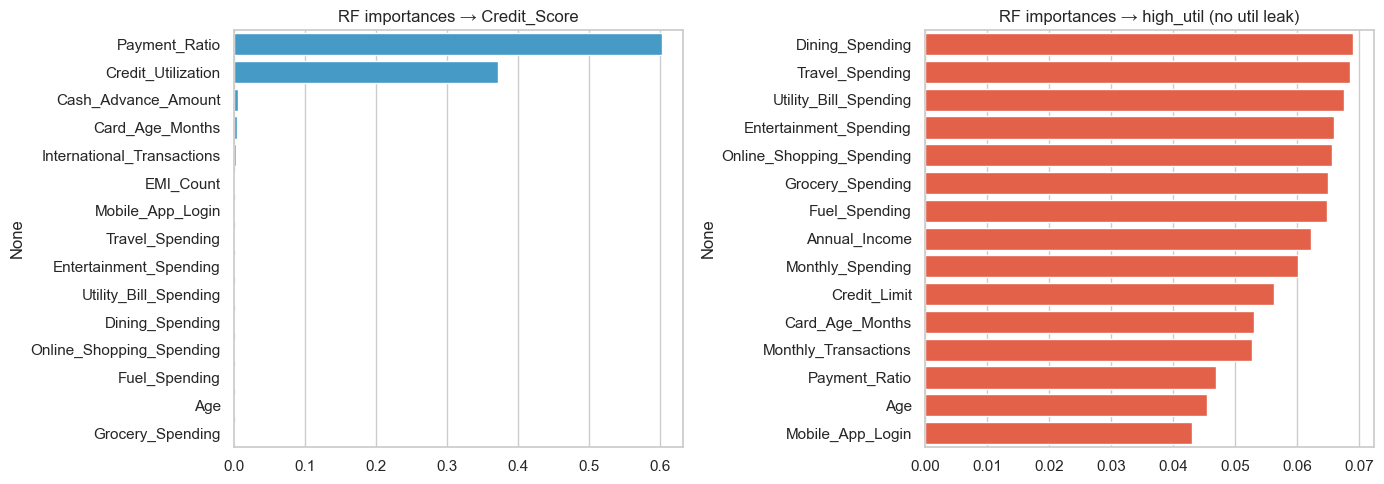

RF in-sample R^2 (Credit_Score): 0.978
RF in-sample accuracy (high_util): 0.872


In [8]:
# RF for Credit_Score (regression) and high_util (classification)
feature_num = [
    "Age", "Annual_Income", "Credit_Limit", "Card_Age_Months", "Monthly_Spending",
    "Monthly_Transactions", "Payment_Ratio", "Credit_Utilization", "Cash_Advance_Amount",
    "EMI_Count", "International_Transactions", "Mobile_App_Login",
] + SPEND_COLS
feature_cat = ["Gender", "Occupation", "Card_Type"]

# Drop Credit_Utilization when predicting high_util (definition leakage)
X = df[feature_num + feature_cat]
y_score = df["Credit_Score"]
pre = ColumnTransformer([
    ("num", "passthrough", feature_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
])
pipe_reg = Pipeline([
    ("pre", pre),
    ("rf", RandomForestRegressor(n_estimators=200, max_depth=12, random_state=7, n_jobs=-1)),
])
pipe_reg.fit(X, y_score)
rf = pipe_reg.named_steps["rf"]
enc = pipe_reg.named_steps["pre"]
names = feature_num + list(enc.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp_score = pd.Series(rf.feature_importances_, index=names).sort_values(ascending=False).head(15)

feat_util = [c for c in feature_num if c != "Credit_Utilization"]
X_u = df[feat_util + feature_cat]
y_u = df["high_util"]
pre_u = ColumnTransformer([
    ("num", "passthrough", feat_util),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cat),
])
pipe_clf = Pipeline([
    ("pre", pre_u),
    ("rf", RandomForestClassifier(n_estimators=200, max_depth=12, random_state=7, n_jobs=-1)),
])
pipe_clf.fit(X_u, y_u)
rf_u = pipe_clf.named_steps["rf"]
enc_u = pipe_clf.named_steps["pre"]
names_u = feat_util + list(enc_u.named_transformers_["cat"].get_feature_names_out(feature_cat))
imp_util = pd.Series(rf_u.feature_importances_, index=names_u).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=imp_score.values, y=imp_score.index, ax=axes[0], color="#30a2da")
axes[0].set_title("RF importances → Credit_Score")
sns.barplot(x=imp_util.values, y=imp_util.index, ax=axes[1], color="#fc4f30")
axes[1].set_title("RF importances → high_util (no util leak)")
plt.tight_layout()
plt.show()
print("RF in-sample R^2 (Credit_Score):", round(rf.score(enc.transform(X), y_score), 3))
print("RF in-sample accuracy (high_util):", round(pipe_clf.score(X_u, y_u), 3))


**Interpretation** <br>
RF importances are exploratory and in-sample — they rank what the tree ensemble used, not causal drivers. Compare the RF shortlist to the linear coef / Pearson tables above: shared leaders are robust generator signals; RF-only leaders hint at interactions or threshold effects. Utilization is left in the score model (behavioral input) but removed from the high-util classifier to avoid definition leakage.



# **10. Optional PCA / KMeans Segments:** <a id="Clusters"></a>



PCA variance explained (2d): [0.456 0.123]


,k,silhouette
0,3,0.179484
1,4,0.178151
2,5,0.179787


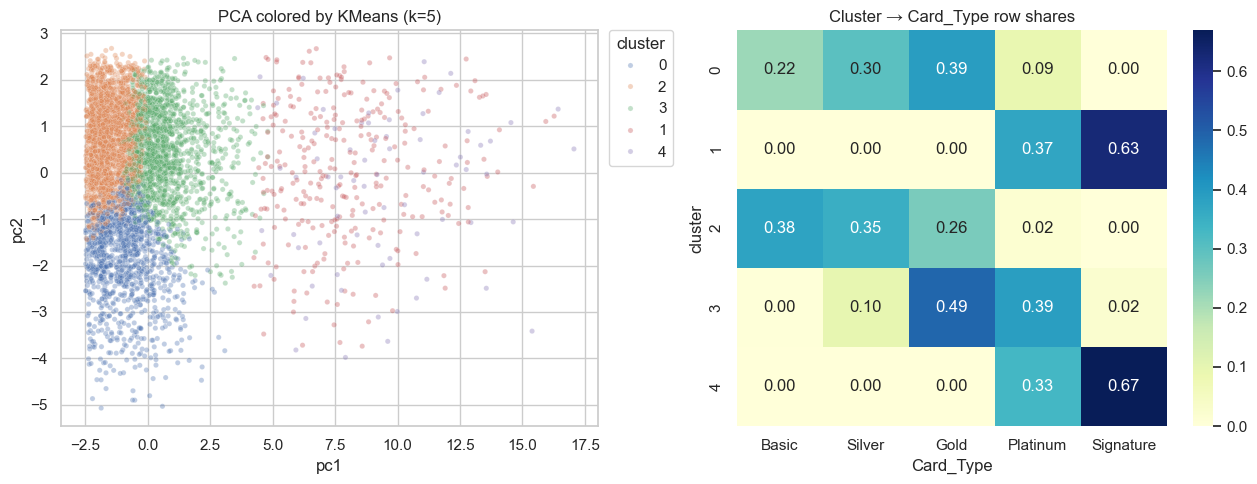

In [9]:
# Scale numeric behavior features → PCA → silhouette for k=3..5
cluster_cols = [
    "Age", "Annual_Income", "Credit_Limit", "Monthly_Spending", "Credit_Utilization",
    "Payment_Ratio", "Credit_Score", "Cash_Advance_Amount", "EMI_Count",
] + SPEND_COLS
X_c = StandardScaler().fit_transform(df[cluster_cols])
pca = PCA(n_components=2, random_state=7)
xy = pca.fit_transform(X_c)
print("PCA variance explained (2d):", pca.explained_variance_ratio_.round(3))

sil_rows = []
labels_by_k = {}
for k in range(3, 6):
    km = KMeans(n_clusters=k, random_state=7, n_init=10)
    labels = km.fit_predict(X_c)
    labels_by_k[k] = labels
    sil_rows.append({"k": k, "silhouette": silhouette_score(X_c, labels, sample_size=8000, random_state=7)})
sil = pd.DataFrame(sil_rows)
display(sil)

best_k = int(sil.loc[sil["silhouette"].idxmax(), "k"])
df["cluster"] = labels_by_k[best_k]
plot = pd.DataFrame({"pc1": xy[:, 0], "pc2": xy[:, 1], "cluster": df["cluster"].astype(str), "Card_Type": df["Card_Type"]})
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=plot.sample(5000, random_state=7), x="pc1", y="pc2", hue="cluster", alpha=0.35, s=14, ax=axes[0])
axes[0].set_title(f"PCA colored by KMeans (k={best_k})")
axes[0].legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ct = pd.crosstab(df["cluster"], df["Card_Type"], normalize="index").reindex(columns=CARD_ORDER)
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Cluster → Card_Type row shares")
plt.tight_layout()
plt.show()


**Interpretation** <br>
Silhouette picks a working k in {3,4,5}. PCA scatter is a compression of behavior space — overlap is expected. Cluster→card shares ask whether unsupervised groups recover the product ladder or cut across it.


# **11. What It Means — Working Synthesis:** <a id="Synthesis"></a>

**What the table is:** <br>
A synthetic 50k-customer credit-card panel with category spend, balances, payment behavior, and credit score.

**Working takeaways:** <br>
- Card mix is Gold-heavy with a thin Signature tail; occupation and income structure the product ladder.
- Spend-mix shares by card test lifestyle differentiation (travel/dining vs grocery/utility).
- Utilization, payment ratio, and score form the risk triangle; `high_util` (≥0.7) is a clean binary drill target.
- Top Pearson correlations shortlist linear associates of `Credit_Score` and flag redundant balance/utilization pairs.
- Standardized linear regression (train/test) ranks controlled score drivers; compare coef order to raw *r* when collinearity bites.
- RF importances (exploratory, in-sample) capture non-linear / interaction signal the linear model misses.
- Optional PCA/KMeans with silhouette over k=3–5 asks whether unsupervised segments recover card tiers.

**Open follow-ups:** <br>
- Partial dependence of Credit_Score on Payment_Ratio at fixed utilization.
- Whether International_Transactions retain signal after Card_Type controls.
- Ridge / ElasticNet if variance inflation among balance features dominates OLS coefs.
- Re-introduce category spend *shares* (not levels) in the score regression once Monthly_Spending is controlled.
- Cluster stability under alternate feature sets (exclude score vs include).
